In [81]:
import numpy as np
import pandas as pd

In [82]:
df=pd.read_csv('Iris.csv')

In [83]:
df.shape
print('Number of Rows:',df.shape[0])
print('Number of Columns:',df.shape[1])

Number of Rows: 150
Number of Columns: 6


In [84]:
print('Column Names:',df.columns.tolist())

Column Names: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [85]:
# print('Data Types: ',df.dtypes)
display(df.dtypes)

,0
Id,int64
SepalLengthCm,float64
SepalWidthCm,float64
PetalLengthCm,float64
PetalWidthCm,float64
Species,object


In [86]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


None

In [87]:
print('Missing values:')
display(df.isnull().sum())

Missing values:


,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [88]:
print('Duplicate Rows:')
print(df.duplicated().sum())

Duplicate Rows:
0


In [89]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [90]:
# The target variable is species
print('Species Distribution: ')
print(df['Species'].value_counts())

Species Distribution: 
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [91]:
print(df['Species'].unique())

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [92]:
numeric_columns=[
    'SepalLengthCm',	'SepalWidthCm',	'PetalLengthCm',	'PetalWidthCm'
]
print((df[numeric_columns]<0).sum())

SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64


In [93]:
#EDA

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

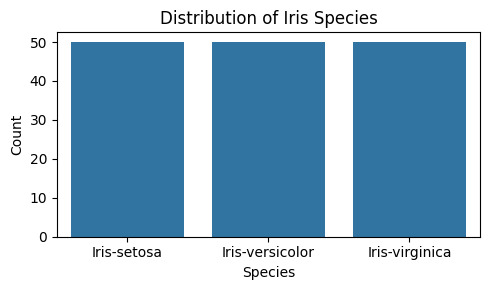

In [95]:
plt.figure(figsize=(5,3))
sns.countplot(
    data=df,
    x='Species'
)
plt.xlabel('Species')
plt.ylabel('Count')
plt.title('Distribution of Iris Species')
plt.tight_layout()
plt.show()

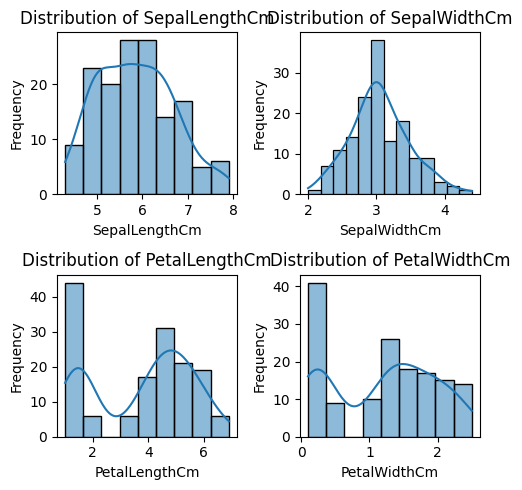

In [96]:
features=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']

plt.figure(figsize=(5,5))
for i,col in enumerate(features,1):
  plt.subplot(2,2,i)
  sns.histplot(
    data=df,
    x=col,
    kde=True
  )
  plt.xlabel(f'{col}')
  plt.ylabel('Frequency')
  plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

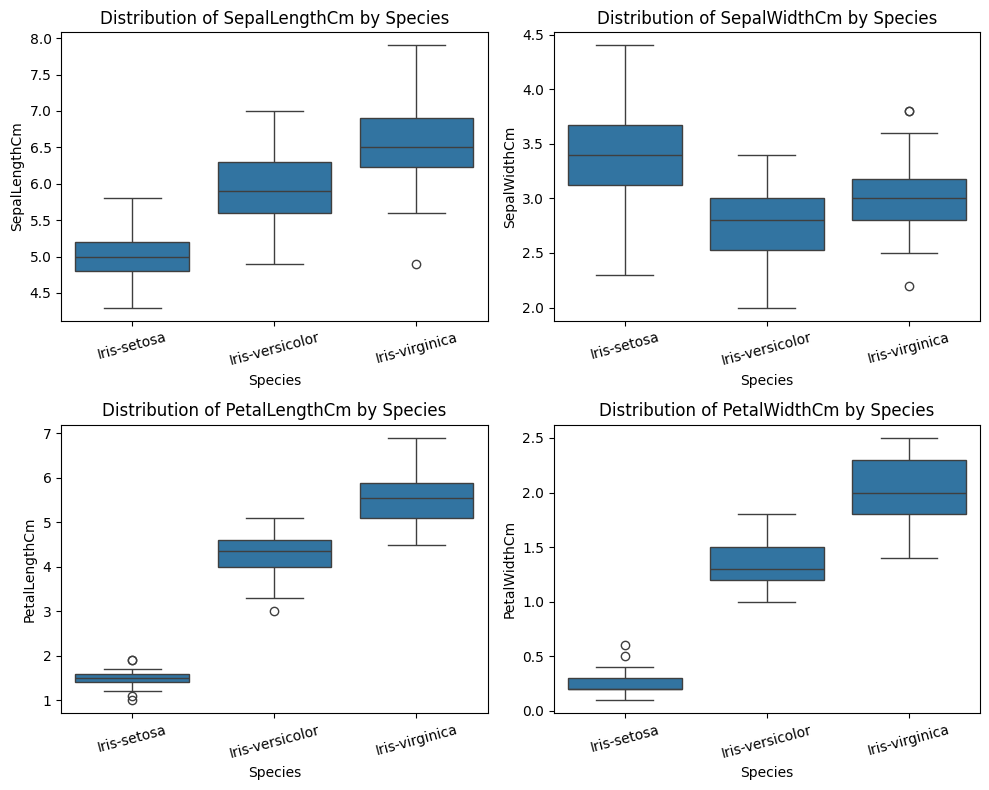

In [97]:
features=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
plt.figure(figsize=(10,8))
for i,col in enumerate(features,1):
  plt.subplot(2,2,i)
  sns.boxplot(
      data=df,
      x='Species',
      y=col
  )
  plt.xlabel('Species')
  plt.ylabel(col)
  plt.title(f'Distribution of {col} by Species')
  plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

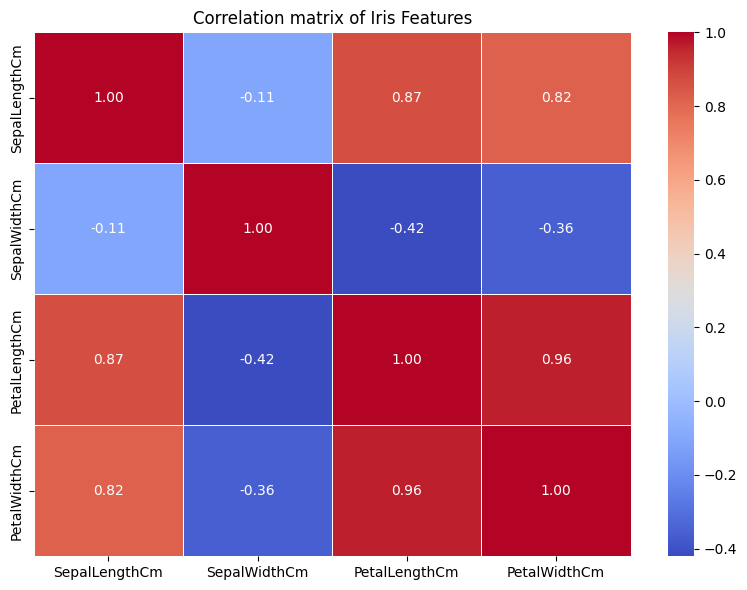

In [98]:
# correlation analysis
correlation_df=df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_df,
    annot=True,
    linewidths=0.5,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation matrix of Iris Features')
plt.tight_layout()
plt.show()

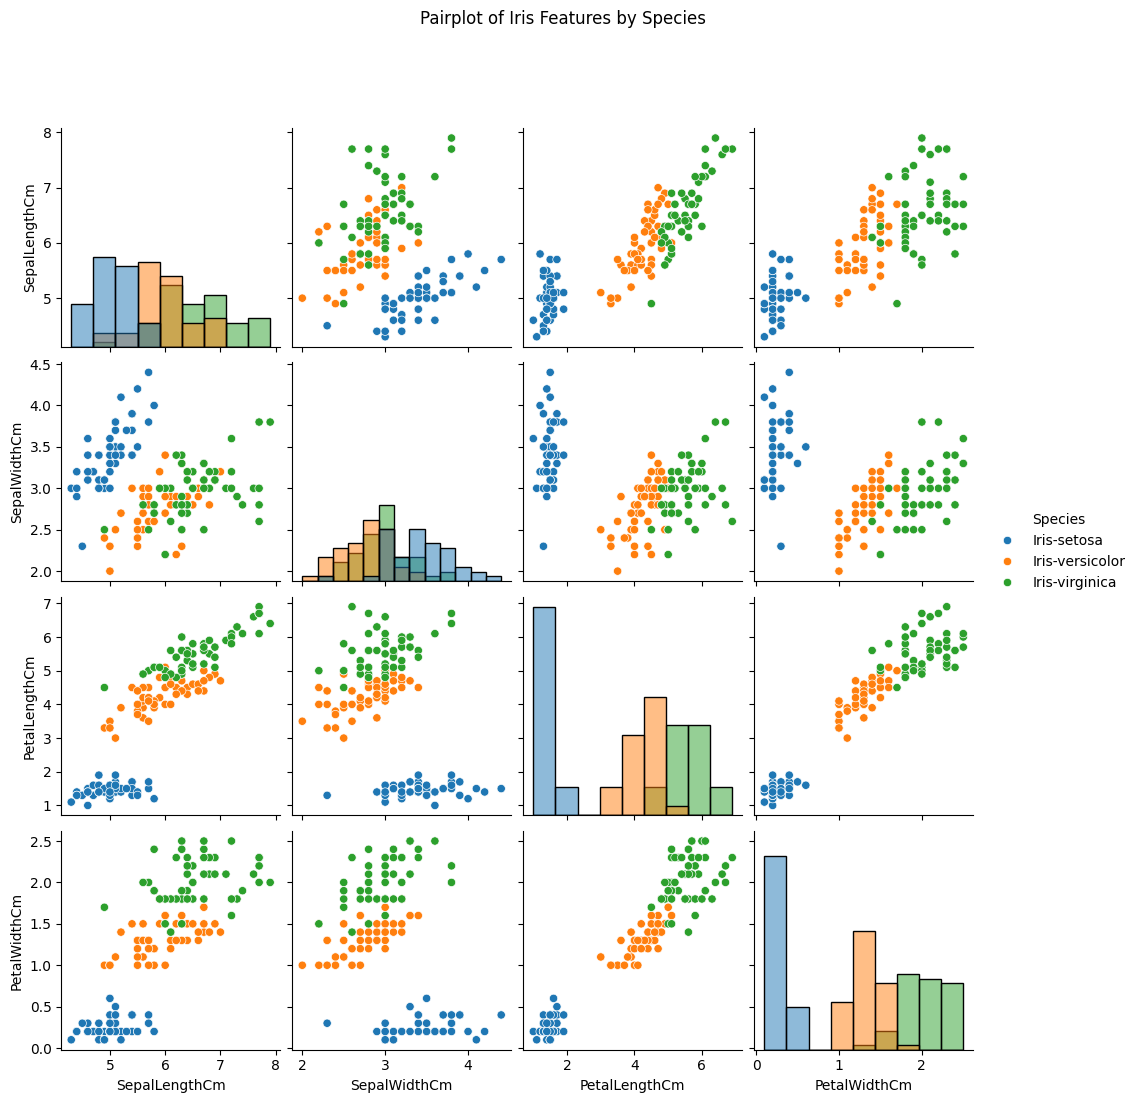

In [99]:
#pairplot for multivariate features relationship
sns.pairplot(
    df,
    vars=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm'],
    hue='Species',
    diag_kind='hist'
)
plt.suptitle('Pairplot of Iris Features by Species',y=1.1)
plt.show()


In [100]:
# Features and Target preparation
features=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
x=df[features]
y=df['Species']
print('Feature Shape:',x.shape)
print('Target Shape:',y.shape)
print('Feature Columns:',x.columns.tolist())
print('Target Values:',y.unique())

Feature Shape: (150, 4)
Target Shape: (150,)
Feature Columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
Target Values: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [101]:
# Train Test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
y=label_encoder.fit_transform(y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print('Training Shape:',x_train.shape)
print('Testing Shape:',x_test.shape)

Training Shape: (120, 4)
Testing Shape: (30, 4)


In [102]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print('Training data shape:',x_train_scaled.shape)
print('Testing data shape:',x_test_scaled.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [103]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
logistic_model=LogisticRegression(random_state=42)
logistic_model.fit(x_train_scaled,y_train)
print('Logistic Regression model loaded successfully')

Logistic Regression model loaded successfully


In [104]:
from sklearn.metrics import accuracy_score,classification_report
y_pred=logistic_model.predict(x_test_scaled)
accuracy=accuracy_score(y_test,y_pred)
print('Accuracy Score:',accuracy)

print('Classification Report: ')
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[str(x) for x in label_encoder.classes_]
    )
)

Accuracy Score: 0.9333333333333333
Classification Report: 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



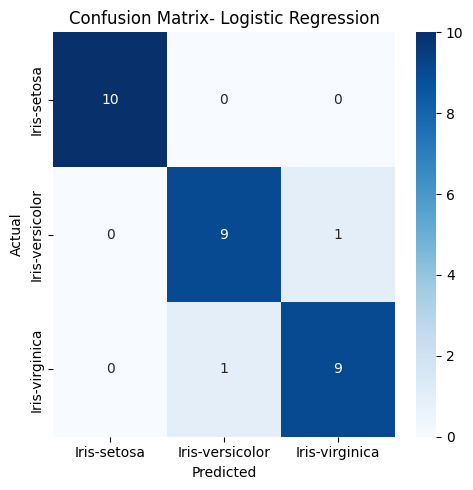

In [105]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix- Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [106]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled,y_train)

KNeighborsClassifier()

In [107]:
from sklearn.metrics import accuracy_score,classification_report
y_pred_knn=knn_model.predict(x_test_scaled)
knn_accuracy=accuracy_score(y_test,y_pred_knn)
print('Accuracy Score: ',knn_accuracy)
print('KNN Classification report: ')
print(
    classification_report(
        y_test,
        y_pred_knn,
        target_names=[str(x) for x in label_encoder.classes_]
    )
)

Accuracy Score:  0.9333333333333333
KNN Classification report: 
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



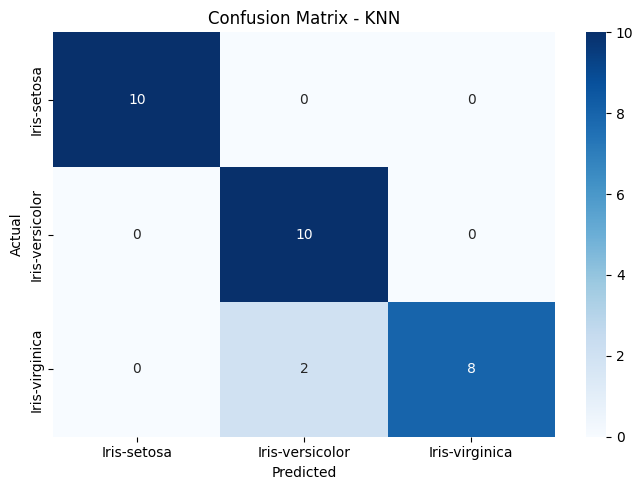

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Plot
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [109]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model=DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [110]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred_dt = decision_tree_model.predict(x_test)

# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

# Classification report
print("\nDecision Tree Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[str(x) for x in label_encoder.classes_]
    )
)

Decision Tree Accuracy: 0.9333333333333333

Decision Tree Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30



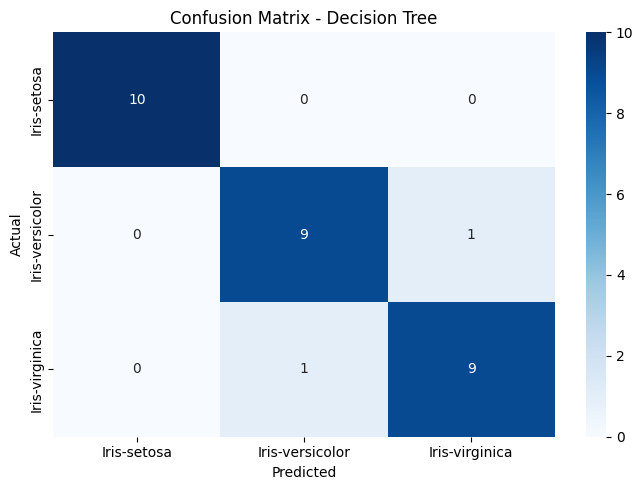

In [111]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [112]:


# Create model comparison
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy,
        knn_accuracy,
        dt_accuracy
    ]
})

print(model_comparison)

                 Model  Accuracy
0  Logistic Regression  0.933333
1                  KNN  0.933333
2        Decision Tree  0.933333


In [113]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate metrics for each model
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt)
    ],
    'Precision': [
        precision_score(y_test, y_pred, average='weighted'),
        precision_score(y_test, y_pred_knn, average='weighted'),
        precision_score(y_test, y_pred_dt, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred_knn, average='weighted'),
        recall_score(y_test, y_pred_dt, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted')
    ]
})

print(model_comparison.round(3))

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.933      0.933   0.933     0.933
1                  KNN     0.933      0.944   0.933     0.933
2        Decision Tree     0.933      0.933   0.933     0.933


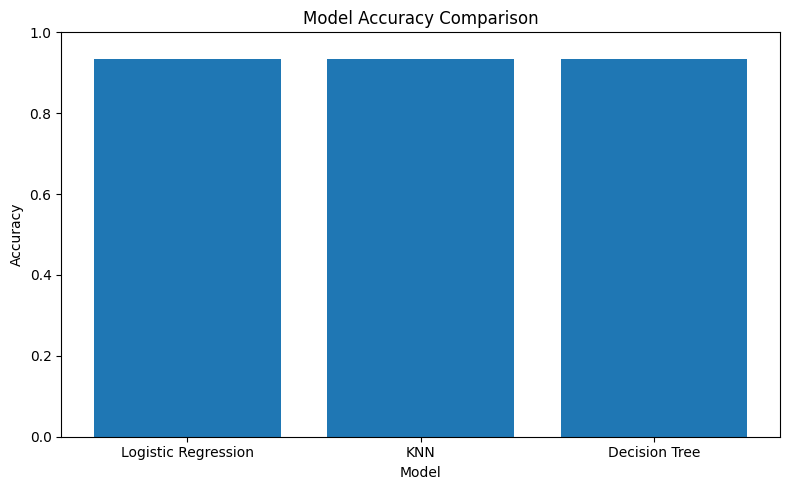

In [114]:
import matplotlib.pyplot as plt

# Plot model accuracy
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison['Model'],
    model_comparison['Accuracy']
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': decision_tree_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

         Feature  Importance
2  PetalLengthCm    0.558568
3   PetalWidthCm    0.406015
1   SepalWidthCm    0.029167
0  SepalLengthCm    0.006250


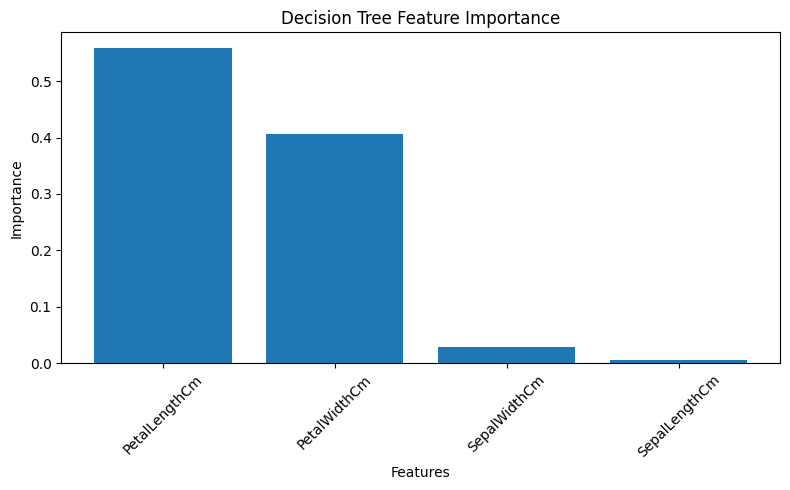

In [116]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Decision Tree Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [117]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Logistic Regression
logistic_cv = cross_val_score(
    logistic_model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Logistic Regression CV Scores:", logistic_cv)
print("Mean CV Accuracy:", logistic_cv.mean())

Logistic Regression CV Scores: [0.91666667 0.95833333 0.95833333 0.95833333 1.        ]
Mean CV Accuracy: 0.9583333333333334


In [118]:
from sklearn.model_selection import cross_val_score

# Cross-validation for KNN
knn_cv = cross_val_score(
    knn_model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("KNN CV Scores:", knn_cv)
print("Mean CV Accuracy:", knn_cv.mean())

KNN CV Scores: [0.91666667 1.         0.95833333 0.95833333 1.        ]
Mean CV Accuracy: 0.9666666666666668


In [119]:
from sklearn.model_selection import cross_val_score

# Cross-validation for Decision Tree
dt_cv = cross_val_score(
    decision_tree_model,
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Decision Tree CV Scores:", dt_cv)
print("Mean CV Accuracy:", dt_cv.mean())

Decision Tree CV Scores: [0.91666667 0.95833333 0.95833333 0.95833333 0.91666667]
Mean CV Accuracy: 0.9416666666666668


In [120]:
final_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Decision Tree'
    ],
    'Test Accuracy': [
        accuracy,
        knn_accuracy,
        dt_accuracy
    ],
    'CV Mean Accuracy': [
        logistic_cv.mean(),
        knn_cv.mean(),
        dt_cv.mean()
    ]
})

print(final_comparison.round(4))

                 Model  Test Accuracy  CV Mean Accuracy
0  Logistic Regression         0.9333            0.9583
1                  KNN         0.9333            0.9667
2        Decision Tree         0.9333            0.9417


In [121]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Scale the complete dataset
final_scaler = StandardScaler()

x_scaled = final_scaler.fit_transform(x)

# Create final KNN model
final_model = KNeighborsClassifier(n_neighbors=5)

# Train on complete dataset
final_model.fit(x_scaled, y)

print("Final KNN model trained successfully!")

Final KNN model trained successfully!


In [122]:
import joblib

# Save final model
joblib.dump(final_model, 'iris_knn_model.pkl')

# Save scaler
joblib.dump(final_scaler, 'iris_scaler.pkl')

# Save label encoder
joblib.dump(label_encoder, 'iris_label_encoder.pkl')


['iris_label_encoder.pkl']

In [123]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]
new_flower_scaled=final_scaler.transform(new_flower)
predict_flower=final_model.predict(new_flower_scaled)
predicted_species=label_encoder.inverse_transform(predict_flower)
print('Predicted Species: ',predicted_species[0])

Predicted Species:  Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Model Interpretation and Key Findings

- The Iris dataset contains three flower species and four numerical features.
- The dataset is balanced across all three species.
- Exploratory Data Analysis showed strong separation between species using petal measurements.
- Logistic Regression, KNN, and Decision Tree achieved 93.33% accuracy on the held-out test set.
- The mean 5-fold cross-validation accuracies were 95.83% for Logistic Regression, 96.67% for KNN, and 94.17% for Decision Tree.
- Decision Tree feature importance indicated that PetalLengthCm and PetalWidthCm were the most influential features.
- The final KNN model successfully predicted a new flower sample as Iris-setosa.